In [1]:
import pandas as pd
import numpy as np
from SynOmics.metrics.narrow_utility.BayesianComparison import BayesianComparison

In [14]:
seeds = [42, 0, 1, 2, 3]
cancers = ["ccRCC", "Melanoma", "NSCLC"]
algo_default = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", 'TVAE']

Cancer_dict = {}

for cancer in cancers:
    score_dict = {}
    for seed in seeds:
        if cancer == 'ccRCC':
            path_os = f"../ccRCC/NarrowUtility/SA/Nivo_Benefit/OS/Seed_{seed}/score_os.csv"
            path_pfs = f"../ccRCC/NarrowUtility/SA/Nivo_Benefit/PFS/Seed_{seed}/score_pfs.csv"
        elif cancer == 'Melanoma':
            path_os = f"../Melanoma/NarrowUtility/SA/SurvivalAnalysis/OS/Seed_{seed}/score_os.csv"
            path_pfs = f"../Melanoma/NarrowUtility/SA/SurvivalAnalysis/PFS/Seed_{seed}/score_pfs.csv"
        else: # NSCLC
            path_os = f"../NSCLC/NarrowUtility/SA/SurvivalAnalysis/OS/Seed_{seed}/score_os.csv"
            path_pfs = f"../NSCLC/NarrowUtility/SA/SurvivalAnalysis/PFS/Seed_{seed}/score_pfs.csv"
        
        try:
            cindex_seed = pd.read_csv(path_os).iloc[1:,:].fillna(0)
            cindex_seed_pfs = pd.read_csv(path_pfs).iloc[1:,:].fillna(0)

            scores_os = np.array(cindex_seed['C-index_score'].values.tolist())
            scores_pfs = np.array(cindex_seed_pfs['C-index_score'].values.tolist())

            avg_scores = (scores_os + scores_pfs) / 2
            score_dict[seed] = avg_scores
        except Exception as e:
            print(f"Error loading {cancer} Seed {seed}: {e}")
            continue

    df_temp = pd.DataFrame(score_dict, index=algo_default).T
    
    Cancer_dict[cancer] = df_temp.to_dict(orient='list')

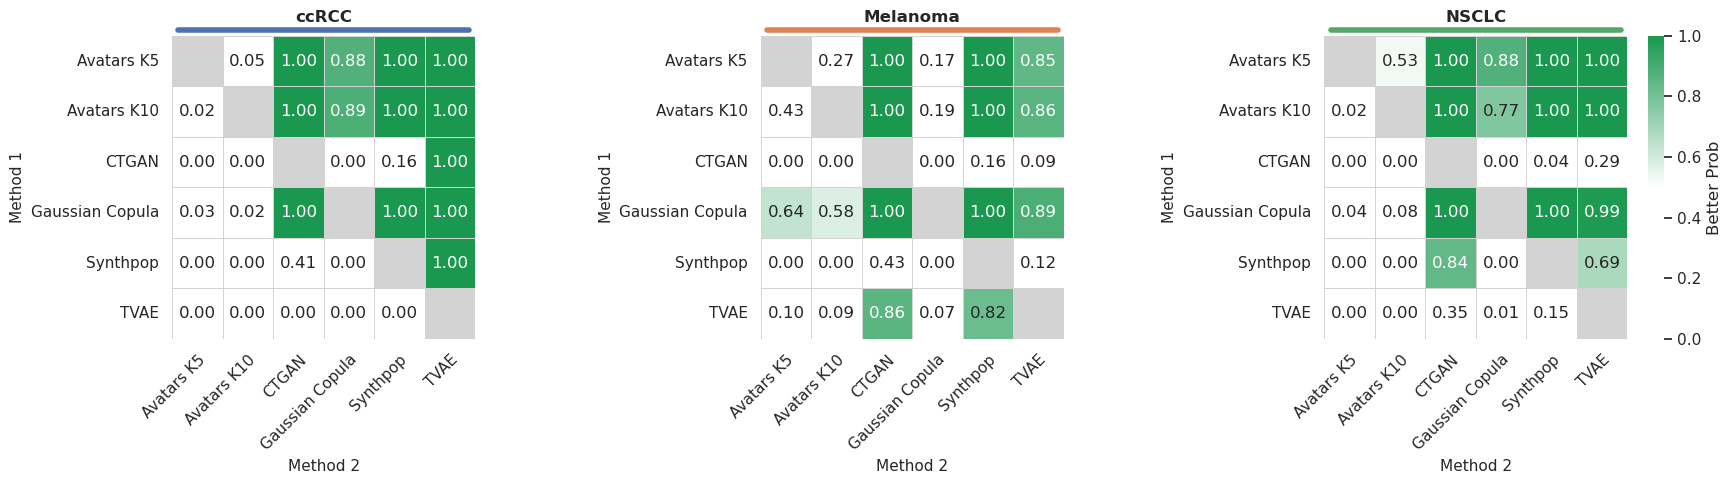

In [15]:
bc = BayesianComparison(rope=0.01)
methods_order = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
fig, axes, mats_by_cancer, comps_by_cancer = bc.plot_pbetter_heatmap_grid(
    cancer_to_method_scores=Cancer_dict,
    cancers_order=("ccRCC", "Melanoma", "NSCLC"),
    methods_order=methods_order,
    value_col="Better Prob",
    figsize = (18,5),
    annot=True,
    fmt=".2f",
    show=True,
)

fig.savefig("bayesian_comp_cindex_score.pdf", bbox_inches="tight", facecolor="white")
for cancer in cancers:
    bayesian_comp_df = comps_by_cancer[cancer]
    bayesian_comp_df.to_csv(f'CIndexScore_Bayesian_{cancer}.csv')

In [20]:
fig.savefig("bayesian_comp_cindex_score.png", bbox_inches="tight", facecolor="white")

In [18]:
print(f"{'Cancer':<12} | {'Tool':<18} | {'Mean':<8} | {'Std':<8}")
print("-" * 55)

for cancer, tools_dict in Cancer_dict.items():
    for tool, scores in tools_dict.items():
        valid_scores = [s for s in scores if s > 0] 
        
        if valid_scores:
            mean_val = np.mean(valid_scores)
            std_val = np.std(valid_scores)
            print(f"{cancer:<12} | {tool:<18} | {mean_val:.3f} | {std_val:.3f}")
        else:
            print(f"{cancer:<12} | {tool:<18} | {'N/A':<8} | {'N/A':<8}")
    print("-" * 55) 

Cancer       | Tool               | Mean     | Std     
-------------------------------------------------------
ccRCC        | Avatars K5         | 0.976 | 0.007
ccRCC        | Avatars K10        | 0.975 | 0.004
ccRCC        | CTGAN              | 0.818 | 0.017
ccRCC        | Gaussian Copula    | 0.947 | 0.014
ccRCC        | Synthpop           | 0.824 | 0.009
ccRCC        | TVAE               | N/A      | N/A     
-------------------------------------------------------
Melanoma     | Avatars K5         | 0.920 | 0.014
Melanoma     | Avatars K10        | 0.925 | 0.023
Melanoma     | CTGAN              | 0.774 | 0.016
Melanoma     | Gaussian Copula    | 0.940 | 0.032
Melanoma     | Synthpop           | 0.781 | 0.017
Melanoma     | TVAE               | 0.849 | 0.061
-------------------------------------------------------
NSCLC        | Avatars K5         | 0.984 | 0.008
NSCLC        | Avatars K10        | 0.973 | 0.007
NSCLC        | CTGAN              | 0.827 | 0.002
NSCLC        | Gauss